In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import string
import os
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
TRAIN_PATH = "twitter_training.csv"
VALIDATION_PATH = "twitter_validation.csv"

train_df = pd.read_csv(
    TRAIN_PATH,
    header=None
)

validation_df = pd.read_csv(
    VALIDATION_PATH,
    header=None
)

print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", validation_df.shape)

Training dataset shape: (74682, 4)
Validation dataset shape: (1000, 4)


In [3]:
columns = [
    "id",
    "entity",
    "sentiment",
    "text"
]

train_df.columns = columns
validation_df.columns = columns

print("Training columns:")
print(train_df.columns.tolist())

print("\nTraining data:")
display(train_df.head())

print("\nValidation data:")
display(validation_df.head())
 
 

Training columns:
['id', 'entity', 'sentiment', 'text']

Training data:


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Validation data:


,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [4]:
print("Training sentiment distribution:")
print(train_df["sentiment"].value_counts())

print("\nValidation sentiment distribution:")
print(validation_df["sentiment"].value_counts())

Training sentiment distribution:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Validation sentiment distribution:
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


In [5]:
# Remove missing values
train_df = train_df.dropna(subset=["text", "sentiment"])
validation_df = validation_df.dropna(subset=["text", "sentiment"])

# Remove Irrelevant class
train_df = train_df[
    train_df["sentiment"].str.strip().str.lower() != "irrelevant"
].copy()

validation_df = validation_df[
    validation_df["sentiment"].str.strip().str.lower() != "irrelevant"
].copy()

print("Training classes:")
print(train_df["sentiment"].value_counts())

print("\nValidation classes:")
print(validation_df["sentiment"].value_counts())

Training classes:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

Validation classes:
sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64


In [6]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove mentions
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Remove hashtag symbol
    text = re.sub(
        r"#",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [7]:
train_df["clean_text"] = train_df["text"].apply(
    clean_text
)

validation_df["clean_text"] = validation_df["text"].apply(
    clean_text
)

display(
    train_df[
        ["text", "clean_text", "sentiment"]
    ].head(10)
)

,text,clean_text,sentiment
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,Positive
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,Positive
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,Positive
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...,Positive
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,Positive
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...,Positive
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...,Positive
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,Positive


In [8]:
train_df = train_df[
    train_df["clean_text"].str.strip() != ""
].copy()

validation_df = validation_df[
    validation_df["clean_text"].str.strip() != ""
].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))

Training samples: 60688
Validation samples: 828


In [9]:
X_train = train_df["clean_text"]

y_train = train_df[
    "sentiment"
].astype(str).str.strip()

X_validation = validation_df["clean_text"]

y_validation = validation_df[
    "sentiment"
].astype(str).str.strip()

In [10]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))

print("\nClasses:")
print(sorted(y_train.unique()))

Training samples: 60688
Validation samples: 828

Classes:
['Negative', 'Neutral', 'Positive']


In [12]:
from sklearn.pipeline import Pipeline
logistic_pipeline = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [13]:
svm_pipeline = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=2000
        )
    )
])

In [14]:
print("Training Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed!"
)

Training Logistic Regression...
Logistic Regression training completed!


In [15]:
print("Training LinearSVC...")

svm_pipeline.fit(
    X_train,
    y_train
)

print(
    "LinearSVC training completed!"
)

Training LinearSVC...
LinearSVC training completed!


In [16]:
logistic_pred = logistic_pipeline.predict(
    X_validation
)

print(
    "Logistic Regression prediction completed!"
)

Logistic Regression prediction completed!


In [17]:
svm_pred = svm_pipeline.predict(
    X_validation
)

print(
    "LinearSVC prediction completed!"
)

LinearSVC prediction completed!


In [18]:
logistic_accuracy = accuracy_score(
    y_validation,
    logistic_pred
)

logistic_precision = precision_score(
    y_validation,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_validation,
    logistic_pred,
    average="weighted"
)

logistic_f1 = f1_score(
    y_validation,
    logistic_pred,
    average="weighted"
)

print("===== Logistic Regression =====")

print(
    "Accuracy:",
    logistic_accuracy
)

print(
    "Precision:",
    logistic_precision
)

print(
    "Recall:",
    logistic_recall
)

print(
    "Weighted F1:",
    logistic_f1
)

===== Logistic Regression =====
Accuracy: 0.9806763285024155
Precision: 0.9807207573550494
Recall: 0.9806763285024155
Weighted F1: 0.9806710904953281


In [19]:
print(
    classification_report(
        y_validation,
        logistic_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       266
     Neutral       0.99      0.97      0.98       285
    Positive       0.97      0.99      0.98       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



In [20]:
svm_accuracy = accuracy_score(
    y_validation,
    svm_pred
)

svm_precision = precision_score(
    y_validation,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_validation,
    svm_pred,
    average="weighted"
)

svm_f1 = f1_score(
    y_validation,
    svm_pred,
    average="weighted"
)

print("===== LinearSVC =====")

print(
    "Accuracy:",
    svm_accuracy
)

print(
    "Precision:",
    svm_precision
)

print(
    "Recall:",
    svm_recall
)

print(
    "Weighted F1:",
    svm_f1
)

===== LinearSVC =====
Accuracy: 0.9842995169082126
Precision: 0.984368284422439
Recall: 0.9842995169082126
Weighted F1: 0.984300128749832


In [21]:
print(
    classification_report(
        y_validation,
        svm_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99       266
     Neutral       0.99      0.98      0.98       285
    Positive       0.98      0.99      0.98       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



In [22]:
comparison = pd.DataFrame({
    
    "Model": [
        "Logistic Regression",
        "LinearSVC"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        svm_precision
    ],
    
    "Recall": [
        logistic_recall,
        svm_recall
    ],
    
    "Weighted F1": [
        logistic_f1,
        svm_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,Weighted F1
0,Logistic Regression,0.980676,0.980721,0.980676,0.980671
1,LinearSVC,0.984300,0.984368,0.984300,0.984300


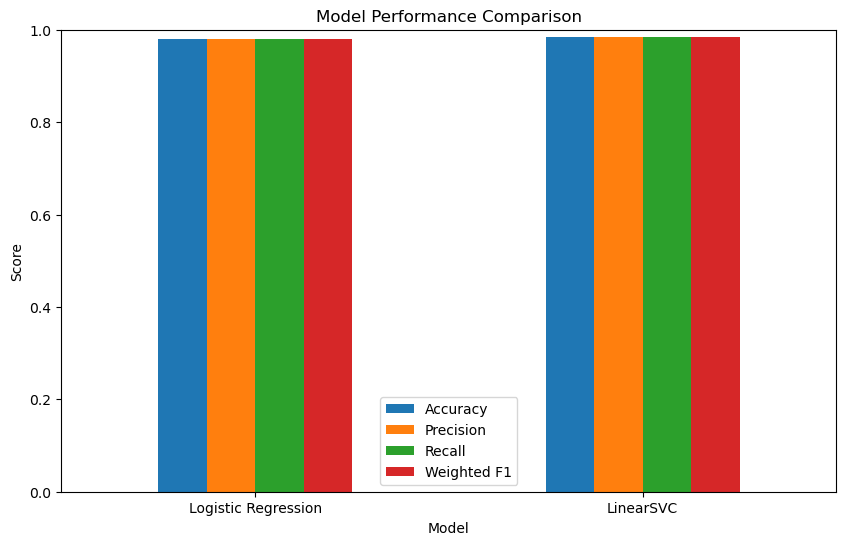

In [23]:
comparison_plot = comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "Weighted F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

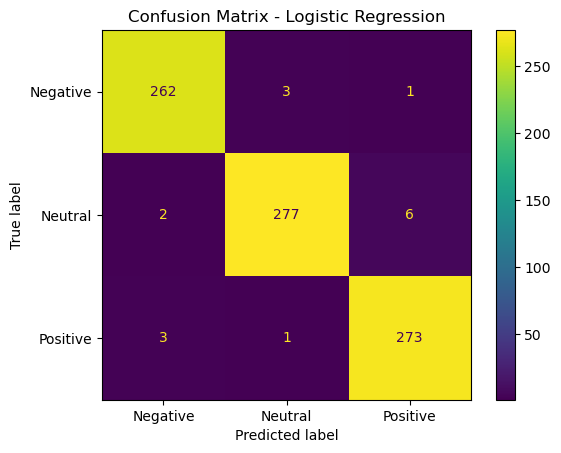

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_pred,
    display_labels=logistic_pipeline.classes_
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.show()

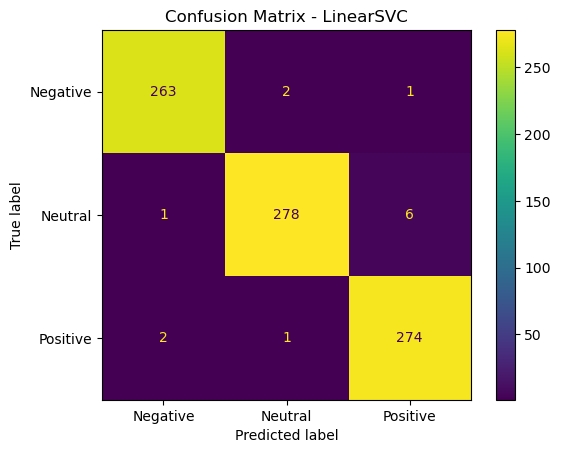

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    svm_pred,
    display_labels=svm_pipeline.classes_
)

plt.title(
    "Confusion Matrix - LinearSVC"
)

plt.show()

In [27]:
if logistic_f1 >= svm_f1:
    
    best_model_name = "Logistic Regression"
    best_pipeline = logistic_pipeline
    best_f1 = logistic_f1

else:
    
    best_model_name = "LinearSVC"
    best_pipeline = svm_pipeline
    best_f1 = svm_f1


print(
    "Best Model:",
    best_model_name
)

print(
    "Best Weighted F1:",
    best_f1
)

Best Model: LinearSVC
Best Weighted F1: 0.984300128749832


In [28]:
os.makedirs(
    "models",
    exist_ok=True
)

In [29]:
joblib.dump(
    logistic_pipeline,
    "models/logistic_pipeline.pkl"
)

joblib.dump(
    svm_pipeline,
    "models/svm_pipeline.pkl"
)

print(
    "Both pipelines saved successfully!"
)

Both pipelines saved successfully!


In [30]:
print(
    "Logistic pipeline exists:",
    os.path.exists(
        "models/logistic_pipeline.pkl"
    )
)

print(
    "SVM pipeline exists:",
    os.path.exists(
        "models/svm_pipeline.pkl"
    )
)

Logistic pipeline exists: True
SVM pipeline exists: True


In [31]:
loaded_logistic = joblib.load(
    "models/logistic_pipeline.pkl"
)

loaded_svm = joblib.load(
    "models/svm_pipeline.pkl"
)

print(
    "Both pipelines loaded successfully!"
)

Both pipelines loaded successfully!


In [32]:
print(
    "Logistic pipeline:",
    loaded_logistic.named_steps.keys()
)

print(
    "SVM pipeline:",
    loaded_svm.named_steps.keys()
)

Logistic pipeline: dict_keys(['tfidf', 'classifier'])
SVM pipeline: dict_keys(['tfidf', 'classifier'])


In [33]:
print(
    "Logistic Regression classes:",
    loaded_logistic.classes_
)

print(
    "LinearSVC classes:",
    loaded_svm.classes_
)

Logistic Regression classes: ['Negative' 'Neutral' 'Positive']
LinearSVC classes: ['Negative' 'Neutral' 'Positive']


In [34]:
print(
    "Logistic Regression classes:",
    loaded_logistic.classes_
)

print(
    "LinearSVC classes:",
    loaded_svm.classes_
)

Logistic Regression classes: ['Negative' 'Neutral' 'Positive']
LinearSVC classes: ['Negative' 'Neutral' 'Positive']


In [36]:
test_texts = [
    "I absolutely love this product!",
    "This is the worst experience ever.",
    "The meeting starts at 10 AM tomorrow.",
    "OMG this new update is amazing!!",
    "I am extremely disappointed with this service.",
    "The package arrived this morning."
]

In [37]:
for text in test_texts:
    
    prediction = loaded_logistic.predict(
        [text]
    )[0]
    
    print(
        "Text:",
        text
    )
    
    print(
        "Logistic Regression:",
        prediction
    )
    
    print("-" * 60)

Text: I absolutely love this product!
Logistic Regression: Positive
------------------------------------------------------------
Text: This is the worst experience ever.
Logistic Regression: Negative
------------------------------------------------------------
Text: The meeting starts at 10 AM tomorrow.
Logistic Regression: Neutral
------------------------------------------------------------
Text: OMG this new update is amazing!!
Logistic Regression: Positive
------------------------------------------------------------
Text: I am extremely disappointed with this service.
Logistic Regression: Negative
------------------------------------------------------------
Text: The package arrived this morning.
Logistic Regression: Neutral
------------------------------------------------------------


In [38]:
for text in test_texts:
    
    prediction = loaded_svm.predict(
        [text]
    )[0]
    
    print(
        "Text:",
        text
    )
    
    print(
        "LinearSVC:",
        prediction
    )
    
    print("-" * 60)

Text: I absolutely love this product!
LinearSVC: Positive
------------------------------------------------------------
Text: This is the worst experience ever.
LinearSVC: Negative
------------------------------------------------------------
Text: The meeting starts at 10 AM tomorrow.
LinearSVC: Neutral
------------------------------------------------------------
Text: OMG this new update is amazing!!
LinearSVC: Positive
------------------------------------------------------------
Text: I am extremely disappointed with this service.
LinearSVC: Negative
------------------------------------------------------------
Text: The package arrived this morning.
LinearSVC: Positive
------------------------------------------------------------


In [39]:
for text in test_texts:
    
    logistic_prediction = loaded_logistic.predict(
        [text]
    )[0]
    
    svm_prediction = loaded_svm.predict(
        [text]
    )[0]
    
    print("Text:", text)
    print(
        "Logistic Regression:",
        logistic_prediction
    )
    print(
        "LinearSVC:",
        svm_prediction
    )
    print("-" * 60)

Text: I absolutely love this product!
Logistic Regression: Positive
LinearSVC: Positive
------------------------------------------------------------
Text: This is the worst experience ever.
Logistic Regression: Negative
LinearSVC: Negative
------------------------------------------------------------
Text: The meeting starts at 10 AM tomorrow.
Logistic Regression: Neutral
LinearSVC: Neutral
------------------------------------------------------------
Text: OMG this new update is amazing!!
Logistic Regression: Positive
LinearSVC: Positive
------------------------------------------------------------
Text: I am extremely disappointed with this service.
Logistic Regression: Negative
LinearSVC: Negative
------------------------------------------------------------
Text: The package arrived this morning.
Logistic Regression: Neutral
LinearSVC: Positive
------------------------------------------------------------
